<a href="https://colab.research.google.com/github/Mali-shaikh/Ali_work/blob/main/Sentiment_Analysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("twitter_training.csv")

In [ ]:
data.isna().sum()

2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on borderlands and i will murder you all ,    686
dtype: int64

In [3]:
data.dropna(inplace = True)

In [4]:
data.drop(["2401","Borderlands"],axis=1, inplace=True)

In [5]:
data.duplicated().sum()

np.int64(3105)

In [6]:
data.drop_duplicates(inplace=True)

In [7]:
data.rename({"Positive": "Output", "im getting on borderlands and i will murder you all ,":"Reviews"}, axis=1, inplace=True)

<Axes: xlabel='Output'>

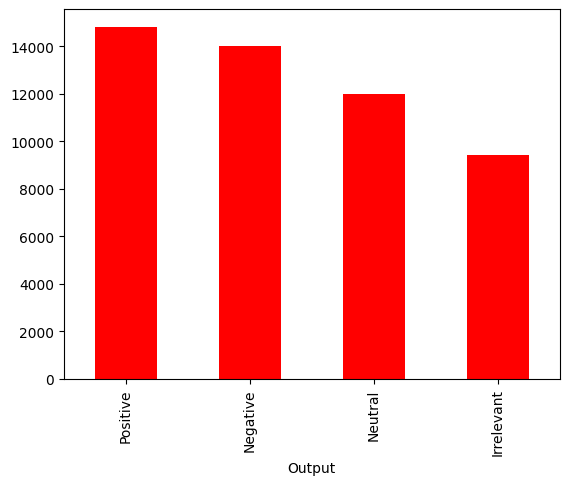

In [8]:
data["Output"].value_counts().plot(kind = "bar", color = "r")

In [10]:
data["Output"].value_counts()

,count
Output,
Positive,14819
Negative,14022
Neutral,11990
Irrelevant,9398


In [11]:
man = {
    "Negative":0,
    "Positive":1,
    "Neutral":2,
    "Irrelevant":3

}

In [12]:
data["Output"]=data.Output.map(man)

In [13]:
data

,Output,Reviews
0,1,I am coming to the borders and I will kill you...
1,1,im getting on borderlands and i will kill you ...
2,1,im coming on borderlands and i will murder you...
3,1,im getting on borderlands 2 and i will murder ...
4,1,im getting into borderlands and i can murder y...
...,...,...
53821,0,@ CfDuty fix their game new omg challenge with...
53822,0,@CallofDuty fix your game new omg challenge re...
53823,0,Dear @CallofDuty fix your stupid game new omg ...
53824,0,@CallofDuty fix your game new omg challenge cu...


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50229 entries, 0 to 53825
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Output   50229 non-null  int64 
 1   Reviews  50229 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


# Preprocessing

In [15]:
!pip install nltk

In [19]:
import nltk
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [22]:
import string
import re
from nltk.corpus import stopwords
def preprocessing(text):
    text= text.lower()
    text = ''.join([i for i in text if i not in string.punctuation])
    text = re.sub("\d+","", text)
    text = ' '.join([i for i in text.split() if i not in stopwords.words("english")])
    return text

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-978961653.py:7: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub("\d+","", text)


In [23]:
data["Reviews"]= data["Reviews"].apply(preprocessing)

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [30]:
toke = Tokenizer()
toke.fit_on_texts(data["Reviews"])
data["Reviews"]= toke.texts_to_sequences(data["Reviews"])

In [27]:
toke.word_index

{'game': 1,
 'like': 2,
 'im': 3,
 'get': 4,
 'one': 5,
 'play': 6,
 'good': 7,
 'really': 8,
 'love': 9,
 'new': 10,
 'see': 11,
 'best': 12,
 'amazon': 13,
 'time': 14,
 'verizon': 15,
 'shit': 16,
 'google': 17,
 'people': 18,
 'dead': 19,
 'microsoft': 20,
 'xbox': 21,
 'still': 22,
 'fifa': 23,
 'games': 24,
 '’': 25,
 'playing': 26,
 'great': 27,
 'red': 28,
 'ps': 29,
 'even': 30,
 'got': 31,
 'dont': 32,
 'go': 33,
 'borderlands': 34,
 'pubg': 35,
 'fucking': 36,
 'home': 37,
 'fuck': 38,
 'cant': 39,
 'much': 40,
 'battlefield': 41,
 'rhandlerr': 42,
 'back': 43,
 'please': 44,
 'overwatch': 45,
 'would': 46,
 'know': 47,
 'redemption': 48,
 'going': 49,
 'day': 50,
 'today': 51,
 'fun': 52,
 'first': 53,
 'series': 54,
 'player': 55,
 'make': 56,
 'csgo': 57,
 'ever': 58,
 'legends': 59,
 'league': 60,
 'us': 61,
 'thanks': 62,
 'also': 63,
 'world': 64,
 'x': 65,
 'thank': 66,
 'bad': 67,
 'depot': 68,
 'fortnite': 69,
 'nbak': 70,
 'ban': 71,
 'want': 72,
 'ive': 73,
 'play

In [31]:
data

,Output,Reviews
0,1,"[281, 4877, 307]"
1,1,"[3, 97, 34, 307]"
2,1,"[3, 281, 34, 1500]"
3,1,"[3, 97, 34, 1500]"
4,1,"[3, 97, 34, 1500]"
...,...,...
53821,0,"[3213, 102, 1, 10, 444, 1199, 264, 2975, 1857]"
53822,0,"[838, 102, 1, 10, 444, 1199, 4144, 2975, 1857]"
53823,0,"[711, 838, 102, 205, 1, 10, 444, 1199, 2975, 1..."
53824,0,"[838, 102, 1, 10, 444, 1199, 1776, 2975, 6064]"


In [33]:
max(len(x) for x in data["Reviews"])

163

In [65]:
X= pad_sequences(data["Reviews"], maxlen=163, padding="post")

In [66]:
X

array([[ 281, 4877,  307, ...,    0,    0,    0],
       [   3,   97,   34, ...,    0,    0,    0],
       [   3,  281,   34, ...,    0,    0,    0],
       ...,
       [ 711,  838,  102, ...,    0,    0,    0],
       [ 838,  102,    1, ...,    0,    0,    0],
       [ 582,    1,  859, ...,    0,    0,    0]], dtype=int32)

In [67]:
y = data["Output"]

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [69]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.SimpleRNN(128, activation="relu",input_shape=(163,1)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(4, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [70]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [71]:
model.fit(X_test,y_test, epochs=15, validation_split=0.2)

Epoch 1/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.2934 - loss: 1.3783 - val_accuracy: 0.2687 - val_loss: 1.3792
Epoch 2/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2838 - loss: 1.3720 - val_accuracy: 0.2811 - val_loss: 1.3812
Epoch 3/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2793 - loss: 1.3741 - val_accuracy: 0.2811 - val_loss: 1.3778
Epoch 4/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2860 - loss: 1.3707 - val_accuracy: 0.2811 - val_loss: 1.3775
Epoch 5/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2745 - loss: 1.3724 - val_accuracy: 0.2811 - val_loss: 1.3780
Epoch 6/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2838 - loss: 1.3728 - val_accuracy: 0.2687 - val_loss: 1.3774
Epoch 7/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2905 - loss: 1.3703 - val_accuracy: 0.2687 - val_loss: 1.3776
Epoch 8/15
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2996 - loss: 1.3690 - val_accu

In [72]:
pred = model.predict(X_test)

314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [73]:
import numpy as np
np.argmax(pred, axis=1)

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
import gradio as gr
